# AI Modified Workflow

For this workflow we use the following prompt to modify the `scale_model_size.py` notebook:

I would like to evaluate the effect of adding in artifial work.  Have PHOLD launch onto 8 nodes and alter the amount passed to its --componentCompute parameter.  Pass values ranging from 0 to 1 million with 5 evenly spaced points.

---

Copilot failed to come up with a working solution due to me giving erroneous instructions in the prompt. It's simple to fix it however, and with that the rest of the solution Copilot gave works although had some code-placement issues.

In several prior notebooks had an issue with Copilot erroneously modifying the "DO NOT MODIFY" section of the "global params" cell to customize workflow parameters.  In this notebook I had the opposite problem.  This new workflow (correctly) adds `num_nodes`, `num_components`, and `component_compute_per_trial` parameters, but rather than adding these new params in the top portion of the cell and supplying them with default values it introduces them in the portion of the cell meant for user-applied overrides.  It also updates the `bmark_args_template` (correctly) to pass in a `--componentCompute`, but again given that this is a fundamental reworking of the overall intent of the workflow it would be desirable to add it to the default functionality rather adding it as an override in the latter section.

Copilot also didn't identify that the `num_comps_per_trial` parameter in this case becomes irrelevant, keeping it as an unused param.

Another issues is that Copilot gave the wrong parameter for my intended workflow.  I screwed up the prompt, explicitly asking that it to use a parameter named `--componentCompute`, but I was mistaken, the correct value is `--componentComputation`. I don't think its unreasonable that Copilot didn't catch my mistake although it certainly would have been nice if it had.

Additionally the set of "component computation" I set were very large, and would, with the current systems we have today, lead to what I would fine to be a feasible but still undesirably large runtime to gather data from.  So to test the notebook out I scaled this down to between 0 and 10,000, which would lead to a total runtime of between 17 to 809 seconds.  All this demonstrates, that if the prompt contains mistakes or poor judgement, that will, of course, carry over to what Copilot does.

---
---
---

# Configuration

## Import workflows module

In [2]:
from utils.workflows import *

## Global params

Users can modify these top-level parameters to alter the behavior of this workflow.

In [ ]:
# ---------------------------------------------------------------------------------------------------------------------
# !!! DO NOT MODIFY THE CODE BELOW   !!!
# !!!  (Modify in the next section)  !!!
# ---------------------------------------------------------------------------------------------------------------------

# So that can you can maintain the defaults, we suggest you don't directly edit
# the parameters inline here but rather overwite values at the bottom of this
# cell.

# We'll store our containers and benchmark results under the specified directory
# (it will be created if it doesn't already exist).
import os
if 'user_customExperimentsDir' in globals():
    baseDir = f'{user_customExperimentsDir}/scale_model_size'
else:
    baseDir=f'{os.getenv("HOME")}/workflows/scale_model_size'

# Run using an SST in the specified container. To find containers to use see the
# container factory at https://github.com/hpc-ai-adv-dev/sst-container-factory
# Prebuild containers are available at https://github.com/orgs/hpc-ai-adv-dev/packages
container_url  = 'ghcr.io/hpc-ai-adv-dev/sst-core:master-latest'
container_name = None # DO NOT MODIFY THIS LINE: Variable will be assigned after we download the container
                      # We include it here to document what global variables are available throughout the
                      # notebook.

# The benchmark will be cloned from the specified repository. We assume the
# benchmark itself is in the 'benchmarkPath' directory within the repos.  We
# assume building the benchmark is a matter of running 'make' in that directoy.
benchmarkRepos='https://github.com/hpc-ai-adv-dev/sst-benchmarks.git'
benchmarkPath='phold'

# Run the benchmark on a single node, increasing the numbers of components with each trial
num_comps_per_trial  = [1_000_000, 2_000_000, 3_000_000, 4_000_000, 5_000_000]

# This command will be run prior to launching a job. The command will be run
# from within the benchmark directory and execution occurs within the worklaunch
# loop so it may be parameterized by the trial parameters if needed.
prestart_cmd_template = ''

# Indicates what arguments should be passed to sst and the benchmark each run 
# Note: {width} and {height} will be replaced with the appropriate values for
# each run, based on the number of nodes and components per node
sst_args_template   = '--print-timing-info=3 --parallel-load=SINGLE ./phold_dist.py'
bmark_args_template = '--width {width} --height {height}'

# Additional arguments to pass when launching jobs with srun. For example the
# partition name or --qos=high for higher priority in the queue.
additional_srun_args = ''

# Several of the setup steps will avoid rerunning if they have previously been run. Append to this
# list to indicate when you want to force a step to be reproduced.
#
# VALID VALUES ARE:
#   'ALL'     
#   'DOWNLOAD_CONTAINERS' 
#   'DOWNLOAD_BENCHMARKS' 
#   'BUILD_BENCHMARKS'      Note: we always rerun make, if this is set we will also run 'make clean' before rebuilding
force = []

# ---------------------------------------------------------------------------------------------------------------------
# Overwite parameters below this line to customize the workflow: 
# ---------------------------------------------------------------------------------------------------------------------


## Environment

In [4]:
set_workflow_log(f'{baseDir}/workflow.log')
run_cmd(f'e4s-cl profile edit --add-files {baseDir}')

> e4s-cl profile edit --add-files /lus/bnchlu1/flash/stonea/experiment/scale_model_size


File /lus/bnchlu1/flash/stonea/experiment/scale_model_size already in profile's files


## Download containers

In [5]:
_force = 'ALL' in force or 'DOWNLOAD_CONTAINERS' in force

container_name = download_custom_container(container_url, force=_force)

Container hpc-ai-adv-dev-sst-core-15.1.2.sif already exists, skipping download.


## Download benchmarks

In [6]:
_force = 'ALL' in force or 'DOWNLOAD_BENCHMARKS' in force

if not os.path.exists(f'benchmarks') or _force:
    run_cmd(f"git clone {benchmarkRepos} benchmarks")
    run_cmd(f"e4s-cl profile edit --add-files {baseDir}/benchmarks/{benchmarkPath}")
else:
    print(f"Benchmarks from {benchmarkRepos} have already been downloaded, skipping download.")

Benchmarks from https://github.com/hpc-ai-adv-dev/sst-benchmarks.git have already been downloaded, skipping download.


## Build benchmarks 

In [7]:
_force = 'ALL' in force or 'BUILD_BENCHMARKS' in force

cd(f"{baseDir}/benchmarks/{benchmarkPath}")
run_cmd('touch sstsimulator.conf')
_cmd = 'make' if not _force else 'make clean; make'
run_in_container(_cmd,
    f'{baseDir}/{container_name}',
    additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')
cd(baseDir)

> touch sstsimulator.conf
> ['apptainer', 'exec', '--no-home', '--bind', '/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold:/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold', '--pwd', '/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold', '--bind', 'sstsimulator.conf:/home/users/stonea/.sst/sstsimulator.conf', '/lus/bnchlu1/flash/stonea/experiment/scale_model_size/hpc-ai-adv-dev-sst-core-15.1.2.sif', 'bash', '-lc', 'make']
sst-register phold phold_LIBDIR=/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold


# Run

## Start jobs

In [8]:
import math, shutil, os

runDisplay = SafeDisplay(display_handle = display('', display_id="run_disp"))

# Setup directory to store results in
run_dir = f'{baseDir}/runs/'
if os.path.exists(run_dir):
    shutil.rmtree(run_dir)
os.makedirs(run_dir, exist_ok=True)

cd(f"{baseDir}/benchmarks/{benchmarkPath}")

# Deploy jobs
for component_compute in component_compute_per_trial:
    width  = int(math.sqrt(num_components))
    height = width
    size = width * height

    if prestart_cmd_template is not None and prestart_cmd_template != '':
        run_cmd(prestart_cmd_template.format(
            width=width,
            height=height,
            size=size,
            component_compute=component_compute,
        ))

    full_sst_args_template = f'{sst_args_template} -- {bmark_args_template}'
    sst_args = full_sst_args_template.format(
        width=width,
        height=height,
        size=size,
        component_compute=component_compute,
    )

    launch_and_log_sst(
        image        = f'{baseDir}/{container_name}',
        srun_args    = f'-N {num_nodes} --job-name={benchmarkPath.lower()}_{component_compute} {additional_srun_args}',
        sst_args     = sst_args,
        log_file     = f'{run_dir}/size_{component_compute}',
        config_path  = f'{baseDir}/benchmarks/{benchmarkPath}/sstsimulator.conf',
        safe_display = runDisplay)

cd(f"{baseDir}")

[+] Using selected profile default
initializing simulation on rank 1 of 8 with 1 threads
[+] Using selected profile default
initializing simulation on rank 2 of 8 with 1 threads
[+] Using selected profile default
initializing simulation on rank 6 of 8 with 1 threads
[+] Using selected profile default
initializing simulation on rank 7 of 8 with 1 threads
[+] Using selected profile default
initializing simulation on rank 5 of 8 with 1 threads
initializing simulation on rank 0 of 8 with 1 threads
initializing simulation on rank 2 of 8 with 1 threads
initializing simulation on rank 3 of 8 with 1 threads
initializing simulation on rank 7 of 8 with 1 threads
initializing simulation on rank 6 of 8 with 1 threads
initializing simulation on rank 5 of 8 with 1 threads
initializing simulation on rank 4 of 8 with 1 threads


------------------------------------------------------------
Simulation Resource Utilization for Code Regions:
■ total
│ ├── Duration: 16.969 seconds
│ └── Memory: Total - 9.4

> SST_CONFIG_FILE_PATH=/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold/sstsimulator.conf e4s-cl launch --image /lus/bnchlu1/flash/stonea/experiment/scale_model_size/hpc-ai-adv-dev-sst-core-15.1.2.sif srun -N 8 --job-name=phold_0  -- sst --print-timing-info=3 --parallel-load=SINGLE ./phold_dist.py -- --width 1000 --height 1000 --componentComputation 0
> SST_CONFIG_FILE_PATH=/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold/sstsimulator.conf e4s-cl launch --image /lus/bnchlu1/flash/stonea/experiment/scale_model_size/hpc-ai-adv-dev-sst-core-15.1.2.sif srun -N 8 --job-name=phold_2500  -- sst --print-timing-info=3 --parallel-load=SINGLE ./phold_dist.py -- --width 1000 --height 1000 --componentComputation 2500
> SST_CONFIG_FILE_PATH=/lus/bnchlu1/flash/stonea/experiment/scale_model_size/benchmarks/phold/sstsimulator.conf e4s-cl launch --image /lus/bnchlu1/flash/stonea/experiment/scale_model_size/hpc-ai-adv-dev-sst-core-15.1.2.sif srun -N 8 --job-nam

## Watch squeue

In [10]:
watch_queue_widget()

Idle

## Inspect results

In [11]:
inspect_logs(f'{baseDir}/runs')

/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_0
/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_2500
/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_5000
/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_7500
/lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/size_10000



# Preprocess

In [12]:
import os, glob

fullpath = f"{baseDir}/runs"
print(f'\n===== running extract under {fullpath} =====')
cd(fullpath)

data = extract_sst_output_in_files(sorted(glob.glob("size_*")))
csv_lines = convert_to_csv(data)
csv_name = f"{baseDir}/runs/results.csv"

with open(csv_name, 'w') as f:
    f.write('\n'.join(csv_lines))

if os.path.exists(csv_name):
    with open(csv_name, 'r') as f:
        print(f'\n===== {csv_name} =====')
        print(f.read())
else:
    print(f'\n===== {csv_name} (not created) =====')


===== running extract under /lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs =====

===== /lus/bnchlu1/flash/stonea/experiment/scale_model_size/runs/results.csv =====
Size,total_duration,total_memory,build_duration,build_memory,graph_processing_duration,graph_processing_memory,construct_duration,construct_memory,execute_time,execute_memory,init_duration,init_memory,setup_duration,setup_memory,run_duration,run_memory,complete_duration,complete_memory,finish_duration,finish_memory,simulated_time,max_resident_set_size,approx_global_max_rss_size,max_local_page_faults,global_page_faults,max_output_blocks,max_input_blocks,max_mempool_usage,global_mempool_usage,global_active_activities,current_global_timevortex_depth,max_timevortex_depth,max_sync_data_size,global_sync_data_size
0,16.969,10094246887.424,7.736,10094246887.424,4.095,4167192018.944,3.641,10094246887.424,9.216,10094246887.424,0.05,10094246887.424,0.027,10094246887.424,8.829,10094246887.424,0.041,10094246887.424,0.018,10

# Plot

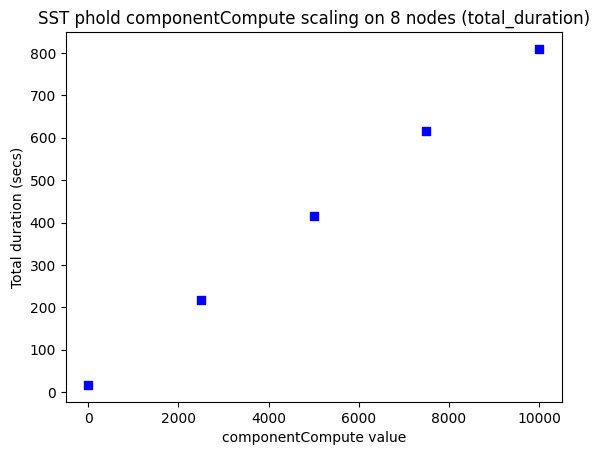

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

try:
    df = pd.read_csv(f"{baseDir}/runs/results.csv")
except FileNotFoundError as e:
    print(f'ERROR: File not found - {e.filename}')
    raise StopExecution()

fig = plt.figure()
ax = fig.add_subplot(111)

plot_value='total_duration'
ylabel = 'Total duration (secs)'

ax.scatter(x=df["Size"], y=df[plot_value], c='b', marker="s", label=f'SST 15.1.0')
ax.legend().remove()
plt.title(f'SST {benchmarkPath} componentCompute scaling on {num_nodes} nodes ({plot_value})')
plt.xlabel('componentCompute value')
plt.ylabel(ylabel)
plt.show()